In [1]:
import numpy as np
import matplotlib.pyplot as plt

## **1) Comparación de grupos**

Vamos a trabajar con dos grupos y a comparar sus resultados.

Supongamos que tenemos:

- **Grupo A:** estudiantes que utilizaron el método tradicional.
- **Grupo B:** estudiantes que utilizaron un nuevo método.

Vamos a utilizar datos sintéticos para calcular:

1. La diferencia de medias.
2. El d de Cohen.
3. La probabilidad de superioridad.

Finalmente, vamos a visualizar los dos grupos.

### 1. Generamos datos sintéticos

Para comenzar, vamos a simular los puntajes de dos grupos.

Supondremos que:

- el Grupo A tiene una media aproximada de 70;
- el Grupo B tiene una media aproximada de 78;
- ambos grupos tienen una desviación estándar aproximada de 10;
- tenemos 40 estudiantes en cada grupo.

La función `np.random.default_rng()` nos permite utilizar un generador
de números aleatorios con una semilla fija, de modo que podamos
reproducir los mismos resultados.

In [12]:
rng = np.random.default_rng(42)

# Datos sintéticos
grupo_A = rng.normal(70, 10, 40)
grupo_B = rng.normal(78, 10, 40)

### 2. Diferencia de medias

Una primera forma de comparar los grupos es calcular la diferencia
entre sus medias:

$$
\Delta = \bar{x}_B - \bar{x}_A
$$

Una diferencia positiva indica que, en promedio, el Grupo B presenta
valores mayores que el Grupo A.

In [13]:
# Diferencia de medias
diff = grupo_B.mean() - grupo_A.mean()

Antes de hablar de Cohen, veamos simplemente cuánto difieren las medias:

In [4]:
print(f"Media del Grupo A: {grupo_A.mean():.2f}")
print(f"Media del Grupo B: {grupo_B.mean():.2f}")
print(f"Diferencia de medias: {diff:.2f}")

Media del Grupo A: 70.38
Media del Grupo B: 78.13
Diferencia de medias: 7.75


### 3. Desviación estándar combinada

Para calcular el d de Cohen necesitamos una medida de la variabilidad
conjunta de los dos grupos.

Utilizamos la **desviación estándar combinada**:

$$
s_{\text{pooled}} =
\sqrt{
\frac{
(n_A-1)s_A^2+(n_B-1)s_B^2
}{
n_A+n_B-2
}
}
$$

Esta medida combina la variabilidad de ambos grupos teniendo en cuenta
el tamaño de cada uno.

In [5]:
# Desviación estándar combinada
n_A = len(grupo_A)
n_B = len(grupo_B)

s_pooled = np.sqrt(
    ((n_A - 1) * grupo_A.var(ddof=1) +
     (n_B - 1) * grupo_B.var(ddof=1))
    / (n_A + n_B - 2)
)

Esta es la medida de variabilidad que vamos a utilizar como referencia para estandarizar la diferencia:

In [6]:
print(f"Desviación estándar combinada: {s_pooled:.2f}")

Desviación estándar combinada: 7.79


### 4. d de Cohen

Ahora podemos calcular el tamaño del efecto mediante el **d de Cohen**:

$$
d =
\frac{\bar{x}_B-\bar{x}_A}
{s_{\text{pooled}}}
$$

El d de Cohen expresa la diferencia entre las medias en unidades
de desviación estándar.

Por ejemplo, un valor de:

$$
d = 0.8
$$

indica que las medias están separadas por aproximadamente
0.8 desviaciones estándar.

In [7]:
# d de Cohen
d = diff / s_pooled

print(f"d de Cohen: {d:.2f}")

d de Cohen: 0.99


Hasta acá tenemos una diferencia de medias y una medida estandarizada de esa diferencia...

### 5. Probabilidad de superioridad

Ahora queremos expresar la diferencia de una manera diferente.

Nos preguntamos:

$$
P(X_B > X_A)
$$

Es decir:

> ¿Cuál es la probabilidad de que una observación elegida al azar
> del Grupo B sea mayor que una observación elegida al azar
> del Grupo A?

Para estimarla con nuestros datos, vamos a comparar cada observación
del Grupo B con cada observación del Grupo A.

Si tenemos 40 observaciones en cada grupo, realizamos:

$$
40 \times 40 = 1600
$$

comparaciones.

In [8]:
# Probabilidad de superioridad
comparaciones = grupo_B[:, None] > grupo_A[None, :]
prob_superioridad = comparaciones.mean()

print(f"Probabilidad de superioridad: {prob_superioridad:.2f}")

Probabilidad de superioridad: 0.76


## 6. A modo de resumen


In [9]:

print(f"Diferencia de medias: {diff:.2f}")
print(f"d de Cohen: {d:.2f}")
print(f"Probabilidad de superioridad: {prob_superioridad:.2f}")

Diferencia de medias: 7.75
d de Cohen: 0.99
Probabilidad de superioridad: 0.76


Podemos resumir la comparación mediante tres cantidades:

- **Diferencia de medias:** expresa la diferencia en las unidades originales.
- **d de Cohen:** expresa la diferencia en unidades de desviación estándar.
- **Probabilidad de superioridad:** expresa la proporción de comparaciones
  en las que una observación del Grupo B supera a una del Grupo A.

Las tres medidas describen la diferencia entre los grupos desde
perspectivas diferentes.

### 7. Visualizamos los grupos

Finalmente, podemos visualizar la distribución de los puntajes
de ambos grupos mediante histogramas.

También vamos a marcar sus medias con líneas verticales.

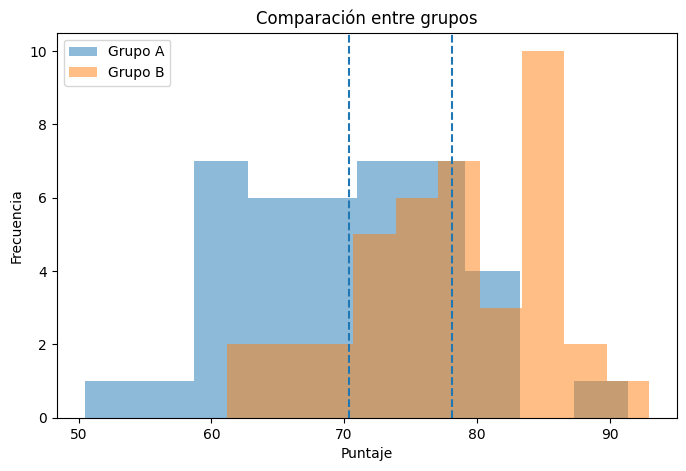

In [10]:
plt.figure(figsize=(8, 5))

plt.hist(grupo_A, alpha=0.5, label="Grupo A")
plt.hist(grupo_B, alpha=0.5, label="Grupo B")

plt.axvline(grupo_A.mean(), linestyle="--")
plt.axvline(grupo_B.mean(), linestyle="--")

plt.xlabel("Puntaje")
plt.ylabel("Frecuencia")
plt.title("Comparación entre grupos")
plt.legend()
plt.show()

### ¿Qué podemos observar?

El gráfico nos permite ver:

- cómo se distribuyen los valores de cada grupo;
- dónde se encuentran aproximadamente sus medias;
- cuánto se superponen las distribuciones.

La diferencia entre las medias nos da una primera descripción,
mientras que el d de Cohen y la probabilidad de superioridad
nos permiten expresar esa diferencia de otras maneras.